<a href="https://colab.research.google.com/github/244107020170-png/machine-learning/blob/main/QUIZ_244107020170_NasywaQonitaRamadhaniHan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In this Quiz #1 you need to perform exploratory data analysis (EDA) and preprocessing using "Census Income" dataset. The dataset is tabular data which has several missing value in some variables. Moreover, you may need to adjust the name of variables (if needed).

To guide you through this task, some code has beed provided including, download the data, loading the data, and metadata inspection.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Part 1 - Data Loading dan Data Imputation

## Task 1 (5 points)
1.   Do inspection to get the information about dataset
2.   **Which variable(s)** has **missing values**? **How many is it**?



In [9]:
# Inspect dataset information
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (48842, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Missing Values:
age                 0
workc

In [10]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("\nVariables with Missing Values:")
print(missing_values)


Variables with Missing Values:
workclass         963
occupation        966
native-country    274
dtype: int64


## Task 2 (5 points)
1. Perform data imputation on missing values.
2. Verified the missing values for each variable. Is it still there?

In [11]:
# Check data types
print(df.dtypes)

# Perform imputation for categorical variables
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna("Others")

# Verify missing values after imputation
print("\nMissing Values After Imputation:")
print(df.isnull().sum())

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Missing Values After Imputation:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [12]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


The missing values were imputed using the value "Others" because, the variables with missing values are categorical variables.
After imputation, there are no missing values remaining in the dataset.

## Task 3 (10 points)
Do inspection to all the quantitative variables (features). If you found an **inappropriate value(s)**, replace it with '**Others**'. Also, if you found any typos value(s), **fix the typos**.

In [13]:
# Inspect unique values of categorical variables
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n=== {column} ===")
    print(df[column].value_counts())


=== workclass ===
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Others                963
Without-pay            21
Never-worked           10
Name: count, dtype: int64

=== education ===
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: in

In [14]:
# Remove unnecessary leading/trailing spaces
for column in categorical_columns:
    df[column] = df[column].str.strip()

In [15]:
print("Categorical values after cleaning:")
for column in categorical_columns:
    print(f"\n=== {column} ===")
    print(df[column].unique())

Categorical values after cleaning:

=== workclass ===
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked' 'Others']

=== education ===
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

=== marital-status ===
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

=== occupation ===
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv' 'Others']

=== relationship ===
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

=== race ===
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

=== sex ===
['Male' 'Female']

=== na

# Part 2 - Visual Inspection


## Task 1 - Data Visualization (20 points)
Do inspection on this following variabels,
1. On the 'age' by using a histogram
2. On the 'education' using a barchart
3. On the 'income' to 'hours_per_week' by using a boxplot (grouped by income)
4. On the 'age' to 'capital-gain' and 'capital-loss' using lineplot (lineplot with multiple x-data)

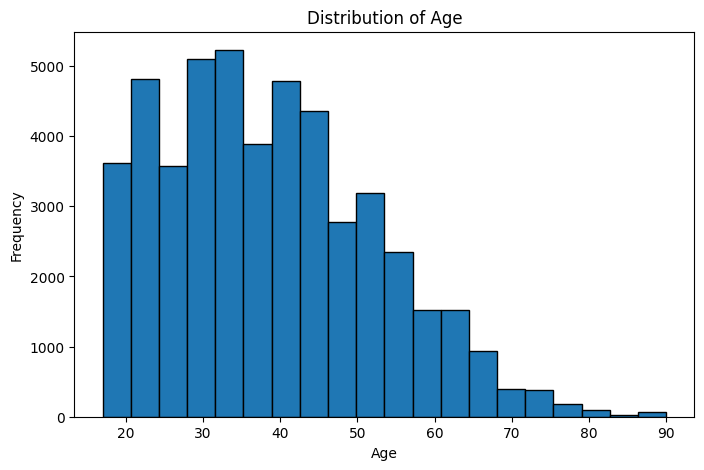

In [16]:
# Answer 1.1 - Histrogram
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

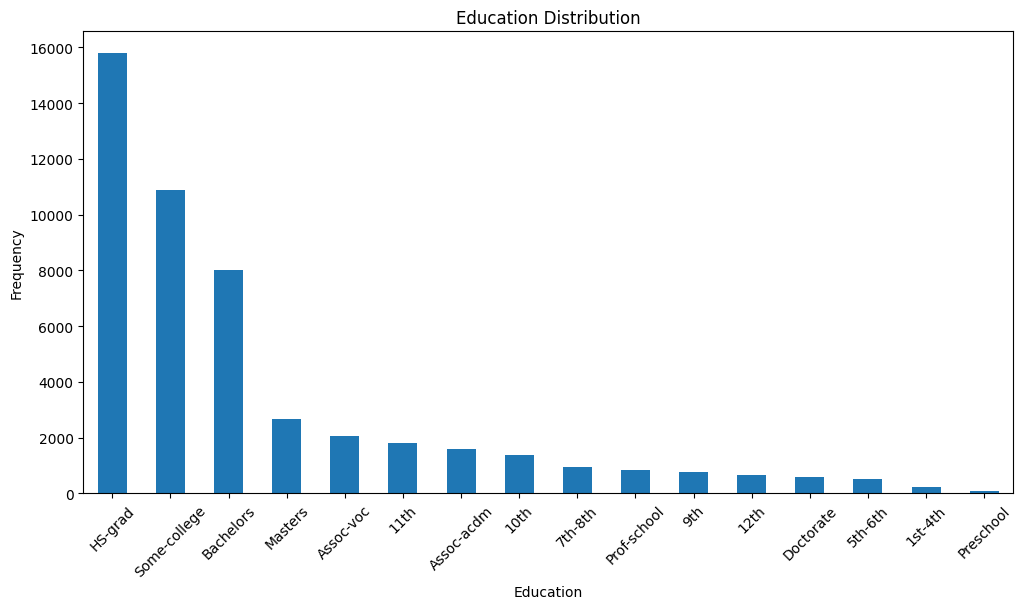

In [17]:
# Answer 1.2 - Barchart
plt.figure(figsize=(12, 6))

df["education"].value_counts().plot(kind="bar")

plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

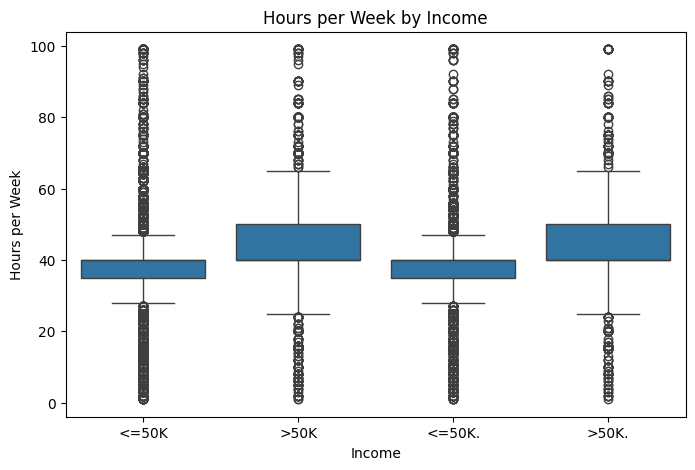

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Hours per Week by Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.show()

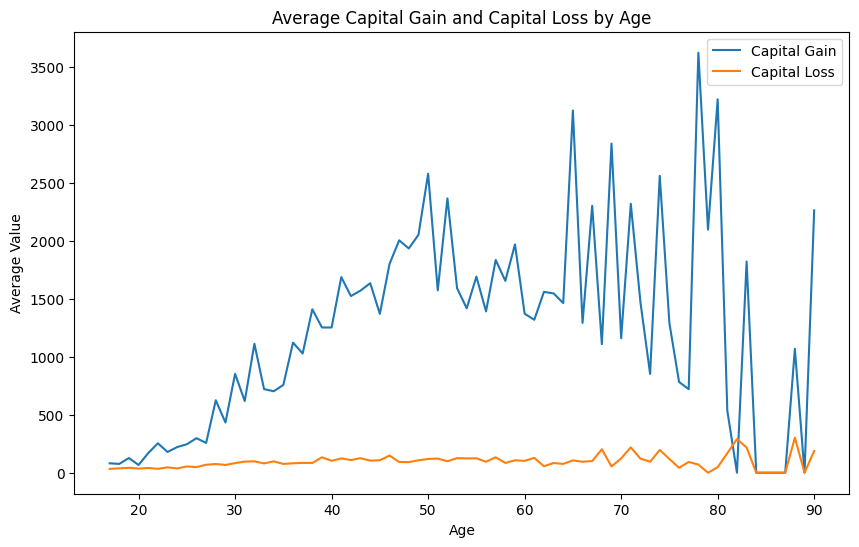

In [21]:
# Answer 1.4 - Lineplot
age_capital = df.groupby("age")[["capital-gain", "capital-loss"]].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=age_capital,
    x="age",
    y="capital-gain",
    label="Capital Gain"
)

sns.lineplot(
    data=age_capital,
    x="age",
    y="capital-loss",
    label="Capital Loss"
)

plt.title("Average Capital Gain and Capital Loss by Age")
plt.xlabel("Age")
plt.ylabel("Average Value")
plt.legend()

plt.show()

## Task 2 - Visual Analysis (15 points)
1. What kind of distribution showed in 'age'?
2. If you find missing values in 'age', what kind of data impute method will you use? Why?
3. How many outliner for each category (group) in 'income' related to 'hour-per-week'? Which category has more outlier?

### 1. Age distribution
The age variable shows a distribution concentrated mainly in the adult age range, with fewer observations at very young and very old ages.

### 2. Missing value imputation
If age contained missing values, the median would be an appropriate imputation method because age is a numerical variable and the median is less sensitive to extreme values than the mean.

### 3. Outliers
The number of outliers for each income category can be obtained from the boxplot using the IQR method.

In [22]:
for income_group in df["income"].unique():
    data = df.loc[df["income"] == income_group, "hours-per-week"]

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]

    print(income_group, ":", len(outliers), "outliers")

<=50K : 7809 outliers
>50K : 510 outliers
<=50K. : 3897 outliers
>50K. : 271 outliers


'\n  Or by using multiple\n  line comments like this\n'


# Part 3 - Encoding in Categorical Variable

## Task 1 (5 points)
Do encoding process on 'Sex' and 'Income', while 'Income' is target variable.

In [23]:
# Encode Sex
df["sex_encoded"] = df["sex"].map({
    "Female": 0,
    "Male": 1
})

# Encode Income
df["income_encoded"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Display result
print(df[["sex", "sex_encoded", "income", "income_encoded"]].head())

      sex  sex_encoded income  income_encoded
0    Male            1  <=50K             0.0
1    Male            1  <=50K             0.0
2    Male            1  <=50K             0.0
3    Male            1  <=50K             0.0
4  Female            0  <=50K             0.0


In [24]:
print(df[["sex_encoded", "income_encoded"]].isnull().sum())

sex_encoded           0
income_encoded    16281
dtype: int64


# Part 4 - Correlation Analysis

## Task 1 (10 points)
1. Do correlation analysis on the following variabels: 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', and 'income' (encoded version from previous task)
2. Based on the result, what kind of information you get?

In [25]:
# Select variables for correlation analysis
correlation_data = df[
    [
        "age",
        "education-num",
        "hours-per-week",
        "capital-gain",
        "capital-loss",
        "income_encoded"
    ]
]

# Calculate correlation
correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                     age  education-num  hours-per-week  capital-gain  \
age             1.000000       0.030940        0.071558      0.077229   
education-num   0.030940       1.000000        0.143689      0.125146   
hours-per-week  0.071558       0.143689        1.000000      0.082157   
capital-gain    0.077229       0.125146        0.082157      1.000000   
capital-loss    0.056944       0.080972        0.054467     -0.031441   
income_encoded  0.234037       0.335154        0.229689      0.223329   

                capital-loss  income_encoded  
age                 0.056944        0.234037  
education-num       0.080972        0.335154  
hours-per-week      0.054467        0.229689  
capital-gain       -0.031441        0.223329  
capital-loss        1.000000        0.150526  
income_encoded      0.150526        1.000000  


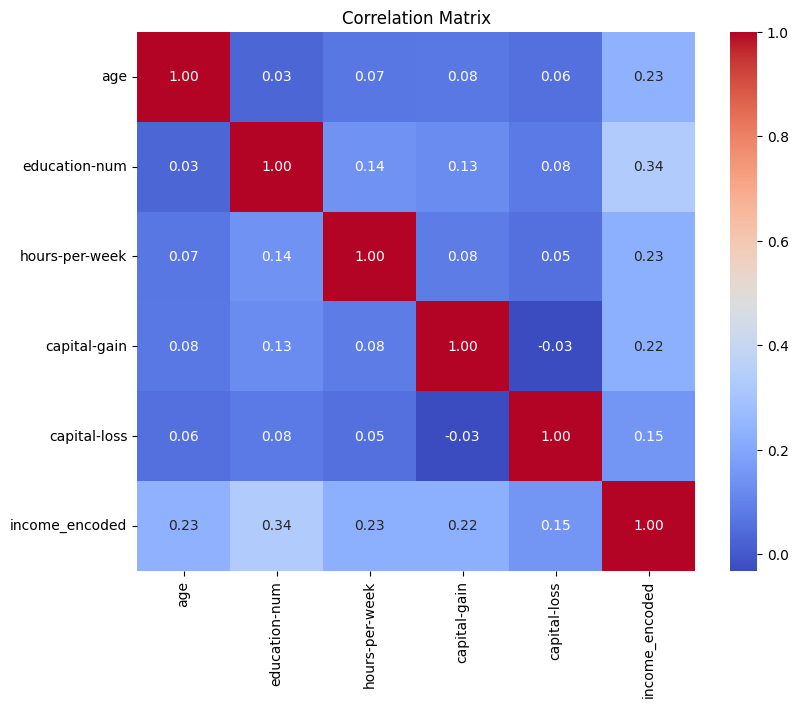

In [26]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

2. The correlation analysis shows the linear relationship between age, education-num, hours-per-week, capital-gain, capital-loss, and the encoded income variable. A positive correlation means that when one variable increases, the other variable tends to increase as well. A negative correlation means that when one variable increases, the other variable tends to decrease. The correlation coefficient is between -1 and 1. Values closer to 1 or -1 indicate stronger relationships, while values closer to 0 indicate weaker linear relationships.

# Part 5 - Preprocessing on MNIST Dataset

In this part, you need to perform EDA and simple preprocessing on MNIST dataset. This dataset contain images of handwritten digit from 0 to 9. A pre configuration is provided to help you to load the data and inspect some images.

Hints:
1. You only need to use the **Test** set.
2. You need to perform to all of images in test set (10k images). You may need a function to complete this task (optional).

In [7]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


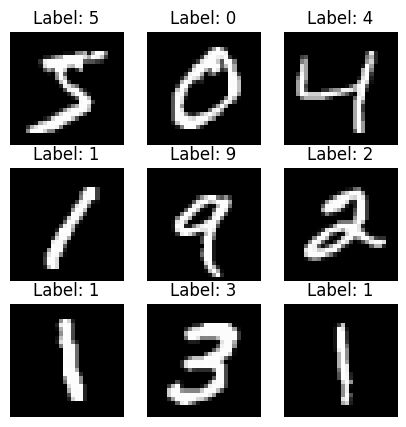

In [8]:
# Visual Inspection
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Task 1 (10 points)
1. Perform **upsampling** on the images to 32x32
2. Show the 5 sample of the result.


Hint: You need to store the result in an empty array. Replacing data to the  **X_test** cannot be done due to the shape of the array (10000, (28,28)). You need to create an array which match with the size of the new images.

In [27]:
from PIL import Image

# Create an empty array for the resized test images
X_test_upsampled = np.empty((X_test.shape[0], 32, 32), dtype=np.uint8)

# Resize all test images from 28x28 to 32x32
for i in range(X_test.shape[0]):
    image = Image.fromarray(X_test[i])
    image = image.resize((32, 32), Image.Resampling.BILINEAR)
    X_test_upsampled[i] = np.array(image)

print("Original test shape:", X_test.shape)
print("Upsampled test shape:", X_test_upsampled.shape)

Original test shape: (10000, 28, 28)
Upsampled test shape: (10000, 32, 32)


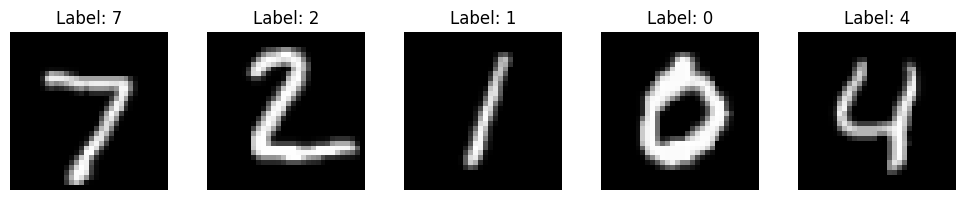

In [28]:
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2 (10 points)
Perform normalization, so the pixel value will have a value in range of 0 until 1

In [29]:
X_test_normalized = X_test_upsampled.astype("float32") / 255.0

print("Minimum pixel value:", X_test_normalized.min())
print("Maximum pixel value:", X_test_normalized.max())
print("Shape:", X_test_normalized.shape)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Shape: (10000, 32, 32)


## Task 3 (10 points)
Transform / reshape the images into 1 dimensional array. Do it to the all images (after resizing and normalization).

Hint: You may need an empty array to store the result

In [31]:
X_test_flattened = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print("Original normalized shape:", X_test_normalized.shape)
print("Flattened shape:", X_test_flattened.shape)

Original normalized shape: (10000, 32, 32)
Flattened shape: (10000, 1024)
